In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

try:
    import pmdarima as pm
except ModuleNotFoundError:
    ! pip install pmdarima
    import pmdarima as pm

try:
    import yfinance as yf
except ModuleNotFoundError:
    ! pip install yfinance
    import yfinance as yf

#### Functions

#### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_dirname_output = './output'

Project: 20250529-intern-template


#### Make output directory

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data

In [4]:
# ticker name
str_ticker_name = 'AAPL'
# last n days
int_n_days = 100
# format a string
print(f'You want to pull {str_ticker_name} stocks for the last {int_n_days} days')

# initialize class
cls_ticker = yf.Ticker(str_ticker_name)
# get last n days
df = cls_ticker.history(period=f'{int_n_days}d')

# save
str_filename = f'df_{str_ticker_name}.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=True)

# show
df

You want to pull AAPL stocks for the last 100 days


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-24 00:00:00-05:00,224.239068,225.087029,220.877183,222.243881,54697900,0.0,0.0
2025-01-27 00:00:00-05:00,223.480912,231.591337,223.440999,229.306854,94863400,0.0,0.0
2025-01-28 00:00:00-05:00,230.294474,239.611994,230.254561,237.686630,75707600,0.0,0.0
2025-01-29 00:00:00-05:00,233.556586,239.282778,233.446850,238.783981,45486100,0.0,0.0
2025-01-30 00:00:00-05:00,238.095637,240.210530,236.639159,237.018234,55658300,0.0,0.0
...,...,...,...,...,...,...,...
2025-06-11 00:00:00-04:00,203.500000,204.500000,198.410004,198.779999,60989900,0.0,0.0
2025-06-12 00:00:00-04:00,199.080002,199.679993,197.360001,199.199997,43904600,0.0,0.0
2025-06-13 00:00:00-04:00,199.729996,200.369995,195.699997,196.449997,51447300,0.0,0.0


#### Plot Open

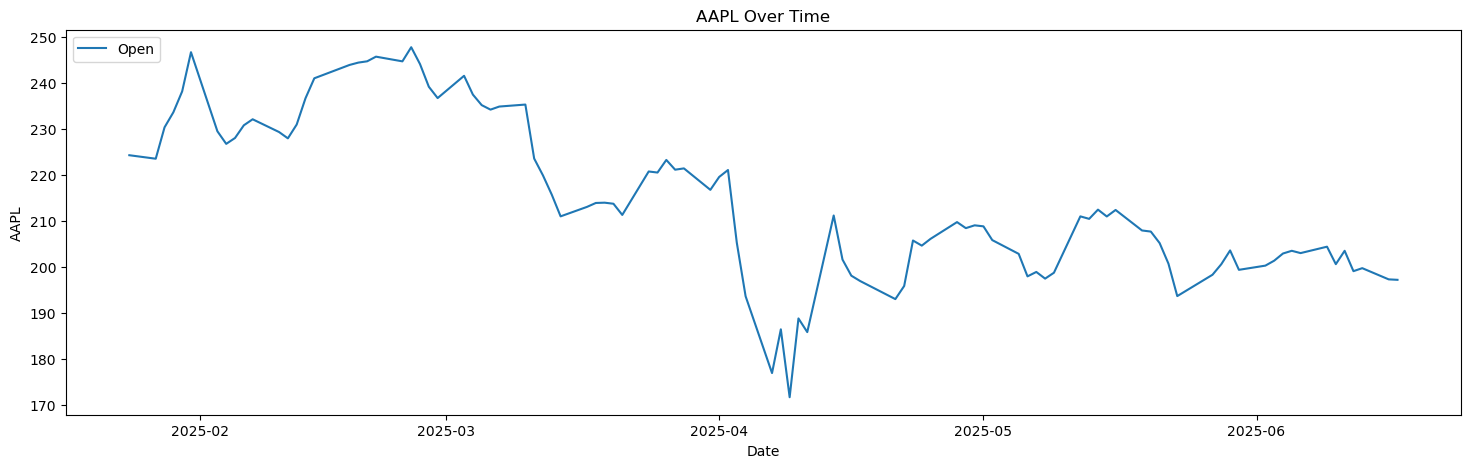

In [5]:
fig, ax = plt.subplots(figsize=(18,5))
# title
str_title = f'{str_ticker_name} Over Time'
ax.set_title(str_title)
ax.set_xlabel('Date')
ax.set_ylabel(str_ticker_name)
# plot open
list_cols = [
    'Open',
    #'Close',
]
for col in list_cols:
    ax.plot(df.index.to_numpy(), df[col].to_numpy(), label=col)

# legend
ax.legend(loc='upper left')

# save
str_filename = f'plt_{str_ticker_name}.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Choose series

In [6]:
ser_values = df['Open']

#### Fit ARIMA (AutoRegressive Integrated Moving Average) model

In [7]:
# initialize
cls_model_inference = sm.tsa.ARIMA(
    ser_values,
    order=(1,1,1), # this can be tuned
)
# fit
results = cls_model_inference.fit()

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Forecast next N days

In [8]:
int_n_days = 10
ser_forecast = results.forecast(steps=int_n_days)
print(ser_forecast)

100    196.541605
101    197.078094
102    196.640937
103    196.997153
104    196.706891
105    196.943411
106    196.750684
107    196.907727
108    196.779761
109    196.884033
Name: predicted_mean, dtype: float64


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


#### Edit index so dates continue from original

In [9]:
idx_forecast = pd.date_range(
    start=ser_values.index[-1] + pd.Timedelta(days=1),
    periods=int_n_days,
    freq='B', # business days
)
print(idx_forecast)

DatetimeIndex(['2025-06-18 00:00:00-04:00', '2025-06-19 00:00:00-04:00',
               '2025-06-20 00:00:00-04:00', '2025-06-23 00:00:00-04:00',
               '2025-06-24 00:00:00-04:00', '2025-06-25 00:00:00-04:00',
               '2025-06-26 00:00:00-04:00', '2025-06-27 00:00:00-04:00',
               '2025-06-30 00:00:00-04:00', '2025-07-01 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', freq='B')


#### Assign index

In [10]:
ser_forecast = pd.Series(
    ser_forecast.values,
    index=idx_forecast,
)
print(ser_forecast)

2025-06-18 00:00:00-04:00    196.541605
2025-06-19 00:00:00-04:00    197.078094
2025-06-20 00:00:00-04:00    196.640937
2025-06-23 00:00:00-04:00    196.997153
2025-06-24 00:00:00-04:00    196.706891
2025-06-25 00:00:00-04:00    196.943411
2025-06-26 00:00:00-04:00    196.750684
2025-06-27 00:00:00-04:00    196.907727
2025-06-30 00:00:00-04:00    196.779761
2025-07-01 00:00:00-04:00    196.884033
Freq: B, dtype: float64


#### Combine original and forecast

In [11]:
ser_forecast = pd.concat([ser_values, ser_forecast])
print(ser_forecast)

2025-01-24 00:00:00-05:00    224.239068
2025-01-27 00:00:00-05:00    223.480912
2025-01-28 00:00:00-05:00    230.294474
2025-01-29 00:00:00-05:00    233.556586
2025-01-30 00:00:00-05:00    238.095637
                                ...    
2025-06-25 00:00:00-04:00    196.943411
2025-06-26 00:00:00-04:00    196.750684
2025-06-27 00:00:00-04:00    196.907727
2025-06-30 00:00:00-04:00    196.779761
2025-07-01 00:00:00-04:00    196.884033
Length: 110, dtype: float64


#### Plot

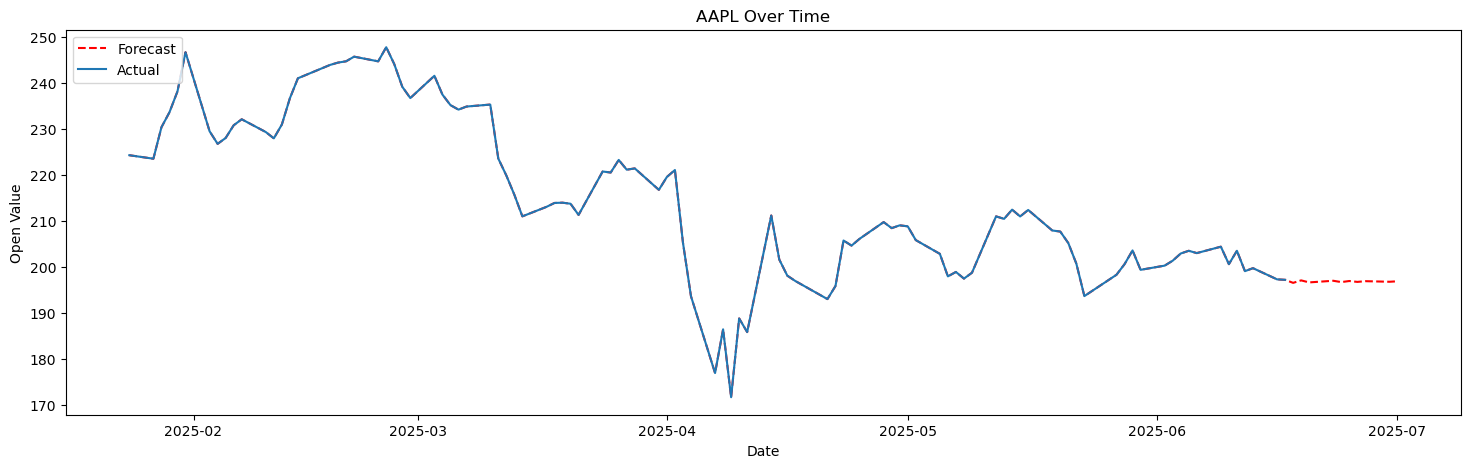

In [12]:
fig, ax = plt.subplots(figsize=(18,5))
# title
str_title = f'{str_ticker_name} Over Time'
ax.set_title(str_title)
ax.set_xlabel('Date')
ax.set_ylabel('Open Value')

# plot forecast
ax.plot(ser_forecast.index, ser_forecast.values, linestyle='--', color='red', label='Forecast')

# plot actual
ax.plot(ser_values.index, ser_values.values, label='Actual')

# legend
ax.legend(loc='upper left')

# save
str_filename = f'plt_{str_ticker_name}_forecast.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Fit Auto ARIMA model

In [13]:
cls_model = pm.auto_arima(
    ser_values,
    seasonal=False, # set to True if you expect seasonality (e.g., monthly sales)
    stepwise=True, # use stepwise search to speed things up
    suppress_warnings=True,
    trace=True, # Set to True to see each trial
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=634.412, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=638.876, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=639.010, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=639.612, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=637.083, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=632.591, Time=0.09 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=635.805, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=634.949, Time=0.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=634.278, Time=0.13 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=633.200, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=633.613, Time=0.09 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=630.770, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=633.947, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=633.225, 

#### Forecast next N days

In [14]:
int_n_days = 10
ser_forecast, arr_conf_int = cls_model.predict(
    n_periods=int_n_days,
    return_conf_int=True,
)
print(ser_forecast, arr_conf_int)

100    196.421032
101    196.673069
102    196.504352
103    196.617294
104    196.541689
105    196.592300
106    196.558420
107    196.581100
108    196.565918
109    196.576081
dtype: float64 [[185.42060925 207.42145448]
 [181.39952498 211.94661343]
 [176.0563737  216.95233039]
 [173.11431497 220.12027216]
 [169.71597227 223.36740573]
 [167.19187168 225.99272773]
 [164.55827811 228.55856234]
 [162.32315609 230.83904311]
 [160.09839699 233.03343846]
 [158.08363381 235.06852754]]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


#### Make data frame

In [15]:
list_dict_row = []
for a in range(int_n_days):
    dict_row = {
        'forecast': ser_forecast.iloc[a],
        'lower': arr_conf_int[a][0],
        'upper': arr_conf_int[a][1],
    }
    list_dict_row.append(dict_row)
df_tmp = pd.DataFrame(list_dict_row)
# show
df_tmp

,forecast,lower,upper
0,196.421032,185.420609,207.421454
1,196.673069,181.399525,211.946613
2,196.504352,176.056374,216.952330
3,196.617294,173.114315,220.120272
4,196.541689,169.715972,223.367406
5,196.592300,167.191872,225.992728
6,196.558420,164.558278,228.558562
7,196.581100,162.323156,230.839043
8,196.565918,160.098397,233.033438
9,196.576081,158.083634,235.068528


#### Edit index so dates continue from original

In [16]:
idx_forecast = pd.date_range(
    start=ser_values.index[-1] + pd.Timedelta(days=1),
    periods=int_n_days,
    freq='B', # business days
)
print(idx_forecast)

DatetimeIndex(['2025-06-18 00:00:00-04:00', '2025-06-19 00:00:00-04:00',
               '2025-06-20 00:00:00-04:00', '2025-06-23 00:00:00-04:00',
               '2025-06-24 00:00:00-04:00', '2025-06-25 00:00:00-04:00',
               '2025-06-26 00:00:00-04:00', '2025-06-27 00:00:00-04:00',
               '2025-06-30 00:00:00-04:00', '2025-07-01 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', freq='B')


#### Assign index

In [17]:
df_tmp.index = idx_forecast
# show
df_tmp

,forecast,lower,upper
2025-06-18 00:00:00-04:00,196.421032,185.420609,207.421454
2025-06-19 00:00:00-04:00,196.673069,181.399525,211.946613
2025-06-20 00:00:00-04:00,196.504352,176.056374,216.952330
2025-06-23 00:00:00-04:00,196.617294,173.114315,220.120272
2025-06-24 00:00:00-04:00,196.541689,169.715972,223.367406
2025-06-25 00:00:00-04:00,196.592300,167.191872,225.992728
2025-06-26 00:00:00-04:00,196.558420,164.558278,228.558562
2025-06-27 00:00:00-04:00,196.581100,162.323156,230.839043
2025-06-30 00:00:00-04:00,196.565918,160.098397,233.033438
2025-07-01 00:00:00-04:00,196.576081,158.083634,235.068528


#### Combine original and forecast

In [18]:
ser_forecast = pd.concat([ser_values, df_tmp['forecast']])
print(ser_forecast)

2025-01-24 00:00:00-05:00    224.239068
2025-01-27 00:00:00-05:00    223.480912
2025-01-28 00:00:00-05:00    230.294474
2025-01-29 00:00:00-05:00    233.556586
2025-01-30 00:00:00-05:00    238.095637
                                ...    
2025-06-25 00:00:00-04:00    196.592300
2025-06-26 00:00:00-04:00    196.558420
2025-06-27 00:00:00-04:00    196.581100
2025-06-30 00:00:00-04:00    196.565918
2025-07-01 00:00:00-04:00    196.576081
Length: 110, dtype: float64


#### Plot

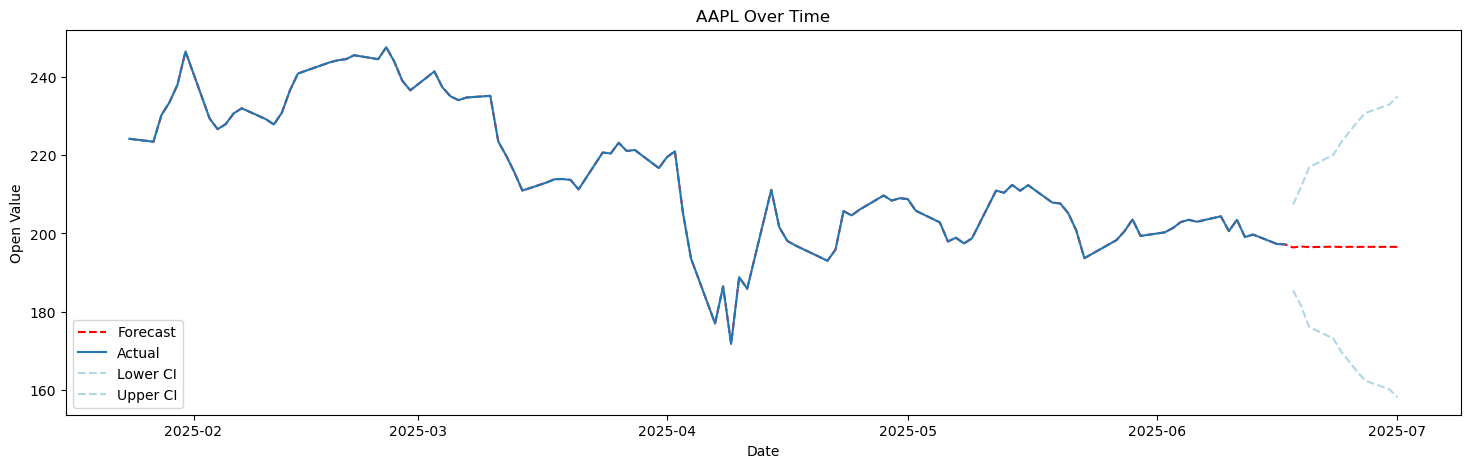

In [19]:
fig, ax = plt.subplots(figsize=(18,5))
# title
str_title = f'{str_ticker_name} Over Time'
ax.set_title(str_title)
ax.set_xlabel('Date')
ax.set_ylabel('Open Value')

# plot forecast
ax.plot(ser_forecast.index, ser_forecast.values, linestyle='--', color='red', label='Forecast')

# plot actual
ax.plot(ser_values.index, ser_values.values, label='Actual')

# plot lower
ax.plot(df_tmp.index, df_tmp['lower'], linestyle='--', color='lightblue', label='Lower CI')

# plot upper
ax.plot(df_tmp.index, df_tmp['upper'], linestyle='--', color='lightblue', label='Upper CI')

# legend
ax.legend(loc='lower left')

# save
str_filename = f'plt_{str_ticker_name}_forecast.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()